I was messing around with the plotting and trying to generate a spectra. The code has some sort of bug but I dont know what it is. Most likely it is because I rushed from the matrix method to a spectra without developing it in an organized way. I know my matrix code is correct since it matches the byu textbook as well as earlier code.  

preliminary Check: 
 1 My importing arrays of functions from exell to python are correct 
 2 my matrix method is reproducing the plot from the byu book. 
 3 i am now going to check if my matrix method is correctly simulating R and T at a single interface- it is correctly doing that.  

 now i am going to try to graph over wavenumber. We need to keep our units consistent for wavelenght, wave number, and d. 

 

In [3]:
%matplotlib widget
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 



file_path = "/Users/josephschellenberg/Downloads/Fresnell.xlsx"
# Load the Excel file (adjust path/filename as needed)
df = pd.read_excel("/Users/josephschellenberg/Downloads/Fresnell/Fresnell.xlsx")  # Or .csv with pd.read_csv

# Extract columns into arrays
wave_numbers = df["wave_numbers"].values
n0_array = df["n0"].values
k0_array = df["k0"].values
n1_array = df["n1"].values
k1_array = df["k1"].values
n2_array = df["n2"].values
k2_array = df["k2"].values 


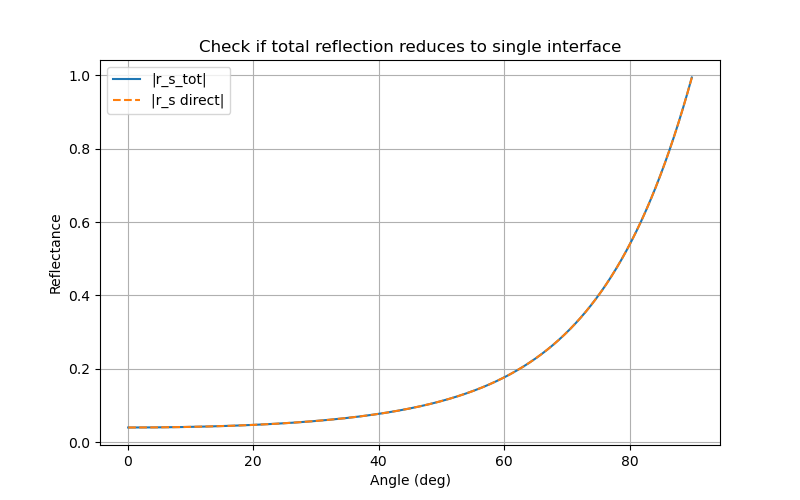

In [5]:


def totalFresnalcoeffPlot(func1, func2, func3, func4):
    fig0 = plt.figure(figsize=(8,5))
    ax0 = fig0.add_subplot(111)
    th0 = np.linspace(0.1,89.9,10000)
    line01, = ax0.plot([],[], 'r--')
    line02, = ax0.plot([],[], 'b--')
    line03, = ax0.plot([],[], 'r-')
    line04, = ax0.plot([],[], 'b-')
    ax0.set_xlim((0,90))
    ax0.set_ylim((-1,1))
    ax0.axhline(0, linewidth=0.75, color='k')
    # ax0.axvline(0, color='k')
    ax0.set_xlabel(r'$\theta_i$')
    ax0.set_ylabel('amplitude coefficient')
    ax0.legend([r'rperptotal, r$_s$', r'tperptotal, t$_s$', r'rparatotal, r$_p$', r'tparatotal, t$_p$'],)
    def plot(n0=1, n1=1.5, n2=1.5, k0=0, k1=0, k2=0, d=1, Wavelength=4):
        output1 = func1(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output2 = func2(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output3 = func3(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        output4 = func4(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)
        line01.set_data(th0, output1)
        line02.set_data(th0, output2)
        line03.set_data(th0, output3)
        line04.set_data(th0, output4)
        plt.draw()
    interact(plot, n0=(0,5,.1), n1=(0,5,.1), n2=(0,5,.1), k0=(0,5,.1), k1=(0,5,.1), k2=(0,5,.1), d=(0,5,.1), Wavelength=(0,5,.1)) 

# 2 Cosine and angle functions 

def cos(th):
    return np.cos(th*np.pi/180) 

def costht(ni, nt, ki, kt, thi):
    return(np.sqrt(1-((ni+1j*ki)/(nt+1j*kt)*sin(thi))**2)) 

def arcsin(ratio):
    return np.arcsin(ratio)*180/np.pi 

def sin(th):
    return np.sin(th*np.pi/180 ) 

# 3 Returns transmitted angle from incident angle
def snells(ni, nt, ki, kt, thi):
    return(arcsin((ni+1j*ki)/(nt+1j*kt)*sin(thi)))

# 4 General form of fresnel coefficients for s polarized light (perpindicular electric field) 
def r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(((ni+1j*ki)/mui*cos_thi-(nt+1j*kt)/mut*cos_tht)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht)) 

def t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)  
    return((2*(ni+1j*ki)/mui*cos_thi)/((ni+1j*ki)/mui*cos_thi+(nt+1j*kt)/mut*cos_tht))

# 5 General form of fresnel coefficients for p polarized light (parrallel electric field)  

def r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((-(nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))

def t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((2*(ni+1j*ki)/mui*cos_thi)/((nt+1j*kt)/mut*cos_thi+(ni+1j*ki)/mui*cos_tht))  


#transmission matrix 

def D_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((1/t_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12))*(np.array([[1,r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12)],[r_p(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12),1]])))  

def D_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    
    return((1/t_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12))*(np.array([[1,r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12)],[r_s(ni, nt, ki, kt, thi, mui=8.85*10**-12, mut=8.85*10**-12),1]])))  


# propagation matrix wich is independant of polarazation

def P(ni, nt, ki, kt, thi, d, Wavelength):
    cos_thi = cos(thi)
    cos_tht = costht(ni, nt, ki, kt, thi)
    return(np.array([[np.exp(1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength),0],[0,np.exp(-1j*2*np.pi*d*(nt+1j*kt)*cos_tht/Wavelength)]]))



# 6 total fresnel coefficints s polarized

def t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    return(1/M_11) 


def t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0]
    return(1/M_11)   

def r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_s_1 = D_s(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_s_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_s_2 = D_s(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_s_1 @ P_s_1 @ D_s_2 
    M_11 = M[0, 0]
    M_21 = M[1, 0]
    return(M_21/M_11) 

def r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    th1 = snells(n0, n1, k0, k1, th0)
    cos_th1 = cos(th1)
    D_p_1 = D_p(n0, n1, k0, k1, th0, mui=8.85*10**-12, mut=8.85*10**-12) 
    P_p_1 = P(n0, n1, k0, k1, th0, d, Wavelength) 
    D_p_2 = D_p(n1, n2, k1, k2, th1, mui=8.85*10**-12, mut=8.85*10**-12) 
    M = D_p_1 @ P_p_1 @ D_p_2 
    M_11 = M[0, 0] 
    M_21 = M[1, 0]
    return(M_21/M_11)   

def mag_r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(r_p_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

def mag_r_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(r_s_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

def mag_t_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(t_p_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0])

def mag_t_s_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength):
    return np.array([np.abs(t_s_tot(n0, n1, n2, k0, k1, k2, d, th, Wavelength)) for th in th0]) 




import numpy as np
import matplotlib.pyplot as plt

th0 = np.linspace(0.1, 89.9, 1000)
r_tot = np.array([r_s_tot(1, 1.5, 1.5, 0, 0, 0, 0, th, 1) for th in th0])
r_direct = np.array([r_s(1, 1.5, 0, 0, th) for th in th0])

plt.figure(figsize=(8, 5))
plt.plot(th0, np.abs(r_tot)**2, label='|r_s_tot|')
plt.plot(th0, (np.abs(r_direct))**2, '--', label='|r_s direct|')
plt.legend()
plt.xlabel('Angle (deg)')
plt.ylabel('Reflectance')
plt.title('Check if total reflection reduces to single interface')
plt.grid(True)
plt.show()


I have d and theta which are constant values. I also have my indexes which are lists of values and my vavenumber which is a list of values.
I want to evaluate my rtot/ttot at at each corresponding entry. this means I need to run a function, obtain a value, 
add that value to a list and then rerun the function. 
Ive found this function that acts like a for loop but keeps my values together. for n, k, wn in zip(n_vals, k_vals, wavenumbers): 

first im going to figure out the eqautionts and correct plot. Once that is done then I will define a plotting function for it. 

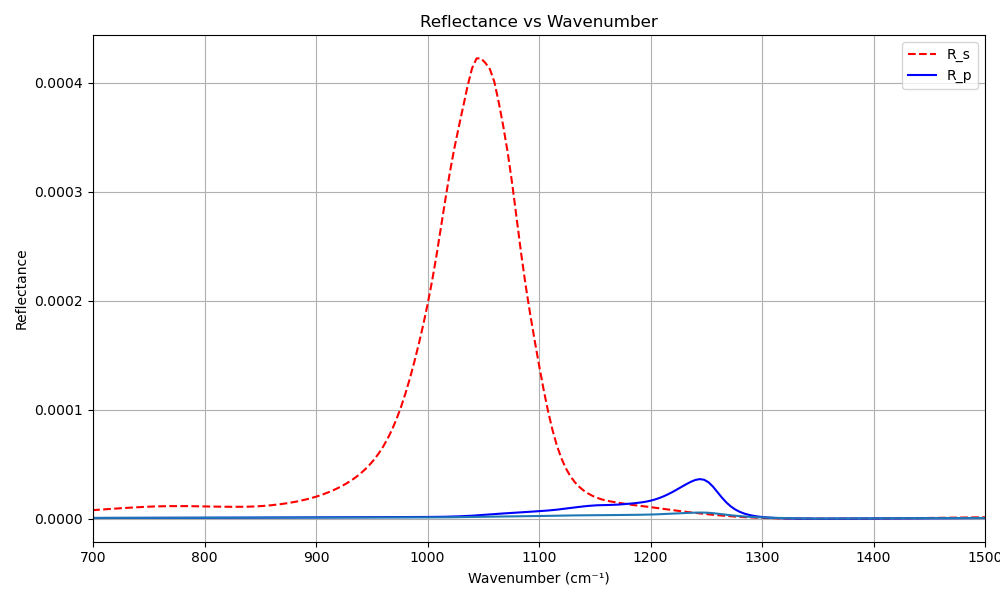

In [42]:
# define d and theta first as global variables
d = .001 
th0=80  
#creating two empty lists for reflectance of parrallel light and the reflectance coefficient. my for loop will add terms to this list using append. 
rparrallel = []
Rparrallel = []
#create my loop 
for n0, k0, n1, k1, n2, k2, Wavenumber in zip(n0_array, k0_array, n1_array, k1_array, n2_array, k2_array, wave_numbers): 
    Wavelength = 10E6 / Wavenumber 
 # converts wavenumber in inverse cm to wavelength in standard nm units. To check a wavenumber of 4000cm^-1 is a wavelenghth of 2500. x=10E6/4000 print (x)  
    r = np.abs(r_p_tot(n0, n1, n2, k0, k1, k2, d, th0, Wavelength)) 
    R = r**2 
    rparrallel.append(r) 
    Rparrallel.append(R) 

#quick graph
plt.plot(wave_numbers, rparrallel)
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Reflectance")
plt.title("Reflectance vs Wavenumber")
plt.gca().invert_xaxis()  # optional: IR plots often have high cm⁻¹ on the left
plt.grid(True)
plt.show()

2500.0
